# Network summary — Dataset 1 (AI4Risk quarterly interbank networks)

Structural characteristics of the network for every quarter (2016 Q1 – 2023 Q4):
number of nodes/edges, density, average degree, reciprocity, clustering coefficient,
assortativity, connected components, average path length and diameter.

Outputs (`src/data/network_summary/`):
- `dataset_1_summary_by_quarter.csv` — one row per quarter
- `dataset_1_summary.csv` — mean over the 32 quarters + representative quarter (2023 Q4)
- `dataset_1_layout.csv` — spring-layout coordinates used for the graph figure

The combined table + three-graph figure lives in `../network_summary_table.ipynb`.

In [1]:
import sys
from pathlib import Path

def find_project_root(start=None):
    start = Path(start or Path.cwd()).resolve()
    for path in [start, *start.parents]:
        if (path / 'src').exists() and (path / 'requirements.txt').exists():
            return path
    raise FileNotFoundError('Project root not found.')

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from scipy.sparse.csgraph import shortest_path

OUT_DIR = PROJECT_ROOT / 'src' / 'data' / 'network_summary'
OUT_DIR.mkdir(parents=True, exist_ok=True)
NB_DIR = PROJECT_ROOT / 'src' / 'notebooks' / '00_notes' / 'dataset_1'

from src.data import load_data

REPR_PERIOD = '2023Q4'

## Summary metrics

Clustering, assortativity, path length and diameter use the undirected projection;
path length and diameter are computed on the largest connected component (LCC).

In [2]:
def network_summary(G: nx.DiGraph) -> dict:
    """Structural summary of a directed network.

    Clustering, assortativity, path length and diameter are computed on the
    undirected projection; path length and diameter on its largest connected
    component (BFS distances via scipy, C speed).
    """
    n = G.number_of_nodes()
    m = G.number_of_edges()
    U = nx.Graph(G)  # undirected projection (reciprocal pairs collapse)

    components = list(nx.connected_components(U))
    lcc_nodes = max(components, key=len)
    U_lcc = U.subgraph(lcc_nodes)

    A = nx.to_scipy_sparse_array(U_lcc, format='csr', weight=None)
    D = shortest_path(A, method='D', unweighted=True, directed=False)
    finite = D[np.isfinite(D) & (D > 0)]

    degrees = np.array([d for _, d in G.degree()])  # in + out

    return {
        'n_nodes': n,
        'n_edges': m,
        'density': nx.density(G),
        'avg_degree': degrees.mean(),
        'max_degree': degrees.max(),
        'reciprocity': nx.reciprocity(G),
        'avg_clustering': nx.average_clustering(U),
        'degree_assortativity': nx.degree_assortativity_coefficient(U),
        'n_components': len(components),
        'lcc_size': len(lcc_nodes),
        'lcc_share': len(lcc_nodes) / n,
        'avg_path_length': finite.mean(),
        'diameter': finite.max(),
    }


In [3]:
rows = []
G_repr = None

for year in range(2016, 2024):
    for q in range(1, 5):
        edges, nodes = load_data(year, q)
        G = nx.DiGraph()
        G.add_nodes_from(nodes['index'])
        G.add_edges_from(edges[['Sourceid', 'Targetid']].itertuples(index=False, name=None))
        rows.append({'period': f'{year}Q{q}', **network_summary(G)})
        if f'{year}Q{q}' == REPR_PERIOD:
            G_repr = G

df_quarters = pd.DataFrame(rows)
df_quarters.to_csv(OUT_DIR / 'dataset_1_summary_by_quarter.csv', index=False)
df_quarters

Loaded 2016 Q1: 4548 banks, 11631 edges


Loaded 2016 Q2: 4548 banks, 11632 edges


Loaded 2016 Q3: 4548 banks, 11937 edges


Loaded 2016 Q4: 4548 banks, 11938 edges


Loaded 2017 Q1: 4548 banks, 11939 edges


...

Loaded 2023 Q1: 4548 banks, 12462 edges


Loaded 2023 Q2: 4548 banks, 12463 edges


Loaded 2023 Q3: 4548 banks, 12464 edges


Loaded 2023 Q4: 4548 banks, 12465 edges


,period,n_nodes,n_edges,density,avg_degree,max_degree,reciprocity,avg_clustering,degree_assortativity,n_components,lcc_size,lcc_share,avg_path_length,diameter
0,2016Q1,4548,11631,0.000562,5.114776,1429,0.153211,0.402581,-0.451449,39,4510,0.991645,2.828914,5.0
1,2016Q2,4548,11632,0.000562,5.115215,1297,0.074450,0.517914,-0.450267,167,4382,0.963500,2.815058,6.0
2,2016Q3,4548,11937,0.000577,5.249340,1253,0.054453,0.478361,-0.441089,175,4374,0.961741,2.821391,7.0
3,2016Q4,4548,11938,0.000577,5.249780,1180,0.038867,0.416179,-0.439395,218,4328,0.951627,2.830728,7.0
4,2017Q1,4548,11939,0.000577,5.250220,1104,0.033671,0.335932,-0.444575,238,4309,0.947449,2.860330,6.0
5,2017Q2,4548,11940,0.000577,5.250660,1069,0.030318,0.276025,-0.440959,214,4334,0.952946,2.907498,7.0
6,2017Q3,4548,11941,0.000577,5.251099,1084,0.023114,0.231447,-0.433683,219,4330,0.952067,2.939697,7.0
7,2017Q4,4548,11981,0.000579,5.268690,1049,0.021701,0.193826,-0.438628,177,4372,0.961302,2.988858,7.0
8,2018Q1,4548,12416,0.000600,5.459982,1106,0.021263,0.171993,-0.426558,148,4401,0.967678,3.001869,7.0
9,2018Q2,4548,12417,0.000600,5.460422,1127,0.018362,0.139671,-0.416723,145,4404,0.968338,3.045361,6.0


In [4]:
metric_cols = [c for c in df_quarters.columns if c != 'period']

summary = pd.DataFrame({
    'value': df_quarters[metric_cols].mean(),                     # mean over 32 quarters
    f'value_{REPR_PERIOD}': df_quarters.set_index('period').loc[REPR_PERIOD, metric_cols],
})
summary.index.name = 'metric'
summary.to_csv(OUT_DIR / 'dataset_1_summary.csv')
summary

,value,value_2023Q4
metric,,
n_nodes,4548.000000,4548.000000
n_edges,12299.656250,12465.000000
density,0.000595,0.000603
avg_degree,5.408820,5.481530
max_degree,1100.687500,1031.000000
reciprocity,0.027917,0.018291
avg_clustering,0.120606,0.008660
degree_assortativity,-0.416577,-0.388933
n_components,176.812500,134.000000


## Graph figure (2023 Q4)

Spring layout of the largest connected component of the most recent quarter.
Coordinates are saved so the combined figure notebook can reuse them.

In [5]:
U = nx.Graph(G_repr)
lcc = max(nx.connected_components(U), key=len)
U_lcc = U.subgraph(lcc)

pos = nx.spring_layout(U_lcc, seed=42, iterations=50)
pd.DataFrame([(n, x, y) for n, (x, y) in pos.items()], columns=['node', 'x', 'y']) \
    .to_csv(OUT_DIR / 'dataset_1_layout.csv', index=False)
print(f'layout: {len(pos)} nodes')

layout: 4414 nodes


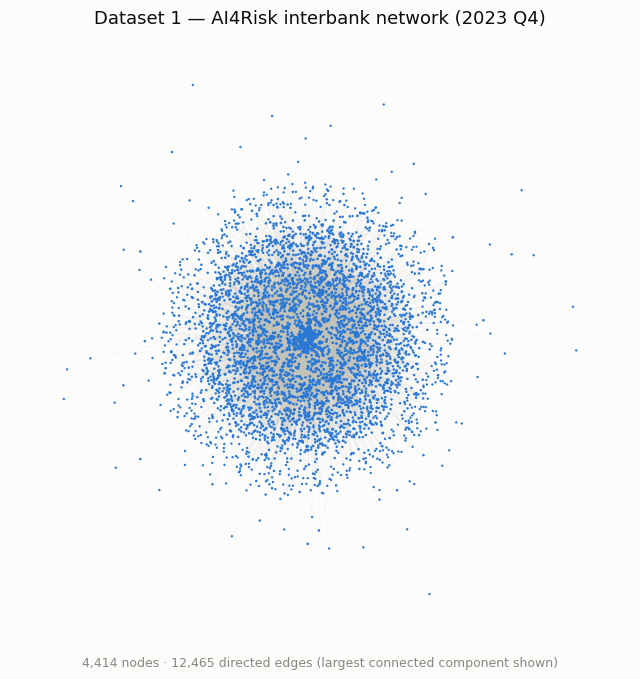

In [6]:
# Figure style (thesis palette)
SURFACE, INK, MUTED, EDGE_COLOR = '#fcfcfb', '#0b0b0b', '#898781', '#c3c2b7'

def draw_network(U_lcc, pos, color, title, subtitle, out_path, ax=None):
    deg = dict(U_lcc.degree())
    s = np.array([deg[n] for n in U_lcc.nodes()], dtype=float)
    sizes = 2 + 28 * np.sqrt(s / s.max())

    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 8), facecolor=SURFACE)
    ax.set_facecolor(SURFACE)
    nx.draw_networkx_edges(U_lcc, pos, ax=ax, edge_color=EDGE_COLOR, alpha=0.15, width=0.3)
    nx.draw_networkx_nodes(U_lcc, pos, ax=ax, node_color=color, node_size=sizes, linewidths=0)
    ax.set_title(title, color=INK, fontsize=13)
    ax.text(0.5, -0.03, subtitle, transform=ax.transAxes, ha='center', color=MUTED, fontsize=9)
    ax.set_axis_off()
    if own_fig:
        fig.savefig(out_path, dpi=200, facecolor=SURFACE, bbox_inches='tight')
        plt.show()

draw_network(
    U_lcc, pos, color='#2a78d6',
    title='Dataset 1 — AI4Risk interbank network (2023 Q4)',
    subtitle=(f'{U_lcc.number_of_nodes():,} nodes · {G_repr.number_of_edges():,} directed edges '
              f'(largest connected component shown)'),
    out_path=NB_DIR / 'dataset_1_graph.png',
)